# Recall: building the ground truth, then measuring against it

One notebook, mirroring the precision one. It builds the ground-truth point set, matches it against
the final detections, and writes `recall_points.csv`.

**What "recall" means here matters.** This measures *pipeline* recall, the probability that a real
installation appears in the final detection product, not classification recall, which asks whether
a classifier fires on an image centred on a known system. The two differ by every loss the pipeline
introduces after classification: tiling, segmentation, polygonisation, filtering. On this data the
gap is 0.84 against 0.61, so a correction built on the classifier's own metric would understate the
required correction by around 40%.

**Two ground-truth sources.**

1. **OpenStreetMap**, extracted from a frozen local dump rather than queried live, which is what
   makes the extraction reproducible. Filters applied here: same-building clustering with summed
   footprints, exclusion of systems above the perimeter, and a temporal filter.
2. **Manual annotation**, a point on or immediately beside an installation, validated visually on
   the imagery.

A point counts as found when it falls inside, or within a small offset of, a detected polygon, and
missed otherwise.


In [1]:
# Repository bootstrap: locate the root, then read every data location from paths.py.
import sys
from pathlib import Path


def _repo_root(start=None):
    start = (start or Path.cwd()).resolve()
    for parent in [start, *start.parents]:
        if (parent / "paths.py").exists() and (parent / "code").is_dir():
            return parent
    raise FileNotFoundError("run this notebook from inside the repository")


sys.path.insert(0, str(_repo_root()))
import paths


## 0. Config

In [2]:
import glob
import hashlib
import string
from pathlib import Path

import geopandas as gpd
import numpy as np
import pandas as pd
from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import connected_components
from scipy.spatial import cKDTree

OSM_EXTRACT_FILE = paths.OSM_PV      # output of osm/extract_osm_pbf.py
MASTER_FILE = paths.ANNOTATIONS_RAW / "recall" / "all_points_recall.geojson"       # historical master, source of the manual points
DATES_FILE = paths.IMAGERY_DATES   # survey date per municipality
CONSERVATIVE_JAN1 = True   # cutoff at 1 January of the municipality's survey year: any point
                           # created before then is CERTAINLY earlier than the image, whatever
                           # day the flight took place. False uses the exact survey date.
MANUAL_GLOB = 'raw/pv_annotation_*.geojson'         # annotations manuelles (tag == 'normal')
DETECTIONS_FILE = paths.DETECTIONS   # final detections, already filtered to the perimeter
DEPARTEMENTS_FILE = paths.DEPARTEMENTS

SRC_CSV = paths.RECALL_SRC          # checkpoint: the ground-truth points retained
OUTPUT_CSV = paths.RECALL_POINTS    # final output, consumed by score_and_aggregation

M2_PER_KWP = 5.5        # conversion aire PLANIMETRIQUE -> puissance. Convention pypvroof : mediane
                        # The reference ratio is measured on the panels' REAL surface, while an
                        # OSM footprint is planimetric and therefore smaller by cos(tilt), 10-15%
                        # a 17-30 degres) -> 6.3 * cos(tilt) ~ 5.5 m2/kWp planimetrique.
                        # Sensibilite : 5.0 (majorant) / 6.5 (defaut constant pypvroof, minorant).
KWP_MAX = 36.0          # exclude systems above the perimeter the registries cover
CLUSTER_M = 25.0        # same-building clustering radius: sub-arrays of one system
DEDUP_M = 25.0          # cross-source deduplication; the OSM identity wins
MATCH_MAX_DIST_M = 20.0 # offset de matching point -> polygone de detection
KEEP_AMBIGUOUS = True   # OSM points edited after the survey: creation date unknown, so
                        # creation inconnue -> conserves si True (flag temporal_status='ambiguous'),
                        # neither certainly before nor after. Sensitivity at the end.

WGS84, LAMBERT93 = 'EPSG:4326', 'EPSG:2154'
LETTERS = string.ascii_uppercase

def stable_id(key, k=14):
    h = hashlib.md5(key.encode()).hexdigest()
    while len(h) < k:
        h += hashlib.md5(h.encode()).hexdigest()
    return ''.join(LETTERS[int(c, 16) % 26] for c in h[:k])


## 1. OpenStreetMap: loading the extract, and the temporal cutoff

Each point's cutoff is the aerial survey date of its **municipality**. In conservative mode it is
pulled back to 1 January of the survey year: a point created before that date is certainly earlier
than the image, whatever day in the year the flight took place. Choosing the conservative side here
costs some ground truth and buys certainty, which is the right trade when the alternative is
silently counting a post-image installation as a miss.

Points outside dated municipalities fall back to the departmental mode of the survey year.

The asymmetry to keep in mind: the model ran over the whole latest release, so any panel present
before the survey was detectable. The only bias needing correction is the panel that appeared
*after* the image.

In [3]:
osm = gpd.read_file(OSM_EXTRACT_FILE)
print(f"{len(osm)} PV objects in {OSM_EXTRACT_FILE} "
      f"({(osm['osm_type'] == 'way').sum()} with a footprint, {(osm['osm_type'] == 'node').sum()} without)")

departements = gpd.read_file(DEPARTEMENTS_FILE)[['code', 'geometry']]

# Unit by spatial join: strict first, then nearest for coastal and border points
osm = gpd.sjoin(osm, departements, how='left', predicate='within').drop(columns='index_right')
missing = osm['code'].isna()
if missing.any():
    nearest = gpd.sjoin_nearest(osm.loc[missing].to_crs(LAMBERT93).drop(columns='code'),
                                 departements.to_crs(LAMBERT93), how='left')
    nearest = nearest[~nearest.index.duplicated(keep='first')]
    osm.loc[missing, 'code'] = nearest['code'].values
    print(f"{missing.sum()} points unassigned by the strict join -> filled by nearest")
osm = osm.rename(columns={'code': 'dept'})
osm = osm[osm['dept'].notna()].reset_index(drop=True)

# --- Cutoff per municipality: the survey date ---
communes = gpd.read_file(DATES_FILE, columns=['insee', 'dpt', 'imagedate'])
communes['imagedate'] = pd.to_datetime(communes['imagedate'], errors='coerce')
communes['cutoff'] = (pd.to_datetime(communes['imagedate'].dt.year.astype('Int64').astype(str) + '-01-01')
                       if CONSERVATIVE_JAN1 else communes['imagedate'])

# The dates file carries one point per municipality, so this is a nearest join.
# A misassignment at a municipal boundary costs at most one vintage, which the
# conservative 1 January cutoff absorbs.
osm = gpd.sjoin_nearest(osm.to_crs(LAMBERT93), communes[['cutoff', 'geometry']].to_crs(LAMBERT93),
                         how='left', distance_col='_d_commune')
osm = osm[~osm.index.duplicated(keep='first')].drop(columns=['index_right', '_d_commune']).to_crs(WGS84)

# fallback : mode departemental de l'annee de prise de vue
dept_year = communes.assign(dpt=communes['dpt'].astype(str).str.zfill(2)) \
    .groupby('dpt')['imagedate'].agg(lambda x: x.dt.year.mode().iloc[0] if x.notna().any() else np.nan)
fallback = pd.to_datetime(osm['dept'].map(dept_year).astype('Int64').astype(str) + '-01-01', errors='coerce')
n_fallback = (osm['cutoff'].isna() & fallback.notna()).sum()
osm['cutoff'] = osm['cutoff'].fillna(fallback)
osm = osm[osm['cutoff'].notna()].reset_index(drop=True)
print(f"cutoff per municipality ({'1 January of the survey year' if CONSERVATIVE_JAN1 else 'exact survey date'}), "
      f"{n_fallback} points through the departmental fallback")
print(osm['cutoff'].dt.year.value_counts().sort_index())

osm['last_edit'] = pd.to_datetime(osm['last_edit'], errors='coerce').dt.tz_localize(None)


72181 PV objects in /sessions/happy-gracious-franklin/mnt/Publication/source/data/intermediate/evaluation/osm_pv_france.geojson (71190 with a footprint, 991 without)
375 points unassigned by the strict join -> filled by nearest


cutoff per municipality (1 January of the survey year), 0 points through the departmental fallback
cutoff
2022     2875
2023    13260
2024    24288
2025    31758
Name: count, dtype: int64


## 2. OpenStreetMap: same-building clustering

Several polygons within a short distance of each other are sub-arrays of one system, three roof
faces mapped separately for instance. They merge into ONE point, at the centroid of the envelope,
with their footprints **summed**.

The order matters, and it is easy to get wrong: this must happen BEFORE the perimeter filter. Three
sub-arrays of 15 kWp make one system of 45 kWp, to be excluded as such, not three systems of 15 kWp
to be kept. Filtering first would keep all three and silently inflate the ground truth with a system
that does not belong in the perimeter.

The cluster's temporal status is the most favourable of its members: the system existed as soon as
any one of its pieces did.

In [4]:
pts_m = osm.to_crs(LAMBERT93)
coords = np.column_stack([pts_m.geometry.x, pts_m.geometry.y])
pairs = cKDTree(coords).query_pairs(r=CLUSTER_M, output_type='ndarray')
n = len(osm)
if len(pairs):
    graph = coo_matrix((np.ones(len(pairs)), (pairs[:, 0], pairs[:, 1])), shape=(n, n))
    _, labels = connected_components(graph, directed=False)
else:
    labels = np.arange(n)
osm['cluster'] = labels

# --- Rehabilitation by source tag ---
# An object mapped AFTER the survey but digitised from a dated orthoimage no later
# than the municipality's own vintage proves the installation existed on the image
# the model saw, so it is requalified as anterior.
#
# Cadastral sources are excluded: a parcel boundary does not prove a panel was
# there. So is any undated imagery source. The requalification has to rest on
# evidence of the panel, not merely on evidence of the building.
import re as _re
_src_df = pd.read_csv(paths.OSM_SOURCES)
_IMG_RE = _re.compile(r'ortho|pcrs', _re.IGNORECASE)
_SRC_YEAR = {}
for _, _r in _src_df.iterrows():
    _txt = str(_r['source'])
    if not _IMG_RE.search(_txt):
        continue
    _years = _re.findall(r'\b(?:19|20)\d{2}\b', _txt)
    if not _years and pd.notna(_r['source_date']):
        _years = _re.findall(r'\b(?:19|20)\d{2}\b', str(_r['source_date']))
    if _years:
        _SRC_YEAR[(_r['osm_type'], int(_r['osm_id']))] = max(int(y) for y in _years)
print(f"sources imagerie datees : {len(_SRC_YEAR)} objets")

# Temporal status per MEMBER: certainly before, certainly after, or ambiguous
def _src_key(osm_id):
    # Identifiers arrive as 'node/123' or 'way/456'
    try:
        t_, i_ = str(osm_id).split('/')
        return (t_, int(i_))
    except (ValueError, AttributeError):
        return None

def member_status(row):
    # Source rehabilitation takes priority over the edit metadata
    y = _SRC_YEAR.get(_src_key(row['osm_id']))
    if y is not None and pd.notna(row['cutoff']) and y <= row['cutoff'].year:
        return 'anterior'
    if pd.isna(row['last_edit']):
        return 'ambiguous'          # no metadata in the dump
    if row['last_edit'] <= row['cutoff']:
        return 'anterior'           # created before, last edited at or before the survey
    if row.get('version') == 1:
        return 'posterior'          # jamais reedite : creation == last_edit > prise de vue
    return 'ambiguous'              # edited after the survey, creation date unknown

osm['temporal_status'] = osm.apply(member_status, axis=1)
_resc = sum(1 for _, r in osm.iterrows()
            if (_y := _SRC_YEAR.get(_src_key(r['osm_id']))) is not None
            and pd.notna(r['cutoff']) and _y <= r['cutoff'].year
            and not (pd.notna(r['last_edit']) and r['last_edit'] <= r['cutoff']))
print(f"rehabilitated by a dated imagery source: {_resc}")

STATUS_PRIORITY = {'anterior': 0, 'ambiguous': 1, 'posterior': 2}
osm_clustered = (
    osm.assign(_prio=osm['temporal_status'].map(STATUS_PRIORITY),
               lon=osm.geometry.x, lat=osm.geometry.y)
    .sort_values('_prio')
    .groupby('cluster')
    .agg(osm_id=('osm_id', 'first'), dept=('dept', 'first'), cutoff=('cutoff', 'first'),
         temporal_status=('temporal_status', 'first'),   # the most favourable member
         area_m2=('area_m2', lambda x: x.sum(min_count=1)),
         n_members=('osm_id', 'size'), lon=('lon', 'mean'), lat=('lat', 'mean'))
    .reset_index(drop=True)
)
print(f"{len(osm)} objects -> {len(osm_clustered)} systems after clustering "
      f"({(osm_clustered['n_members'] > 1).sum()} clusters multi-objets)")


sources imagerie datees : 2515 objets


rehabilitated by a dated imagery source: 2045


72181 objects -> 35030 systems after clustering (8182 clusters multi-objets)


## 3. OpenStreetMap: footprint and temporal filters

**Above the perimeter**: excluded, being outside the segment the registries cover and outside the
pipeline's rooftop target. Points without a footprint are kept, since they are small residential
installations in the overwhelming majority of cases.

**Temporal**: points certainly created after the survey are excluded. Points merely *edited* after
the survey, whose creation date is unknown, are kept by default, with a sensitivity check at the end
of the notebook. Treating an unknown as a certainty in either direction would be the wrong call, so
the choice is made explicit and its cost measured.

In [5]:
osm_clustered['kWp_est'] = osm_clustered['area_m2'] / M2_PER_KWP

too_big = osm_clustered['kWp_est'] > KWP_MAX
posterior = osm_clustered['temporal_status'] == 'posterior'
ambiguous = osm_clustered['temporal_status'] == 'ambiguous'

print(f"exclusions : {too_big.sum()} systemes > {KWP_MAX:.0f} kWp "
      f"({osm_clustered.loc[too_big, 'kWp_est'].sum() / 1000:.1f} MWp), "
      f"{posterior.sum()} certainly later than the survey")
print(f"ambiguous (edited after the survey): {ambiguous.sum()} -- "
      f"{'conserves' if KEEP_AMBIGUOUS else 'exclus'} (KEEP_AMBIGUOUS={KEEP_AMBIGUOUS})")

keep = ~too_big & ~posterior
if not KEEP_AMBIGUOUS:
    keep &= ~ambiguous
osm_final = osm_clustered[keep].copy()
osm_final['source'] = 'OSM'
print(f"-> {len(osm_final)} points OSM retenus")


exclusions : 19831 systemes > 36 kWp (12517.5 MWp), 16676 certainly later than the survey
ambiguous (edited after the survey): 3912 -- conserves (KEEP_AMBIGUOUS=True)
-> 8457 points OSM retenus


## 4. Manual annotation

The historical master plus every point of the annotation exports, taken at the centroid of the
annotation square.

**The tag is not a filter here**, and this is worth stating because it looks like one. Every
annotated point corresponds to a real PV installation; the tag serves other purposes elsewhere.
Filtering on it would discard valid ground truth.

Duplicates across files are deliberate and are cleaned by the deduplication in section 5. These
points were validated visually on the imagery, so they precede the survey by construction.

In [6]:
manual_parts = []

master = gpd.read_file(MASTER_FILE)
m = master.copy()
m['INSEE_DEP'] = m['INSEE_DEP'].astype(str).str.zfill(2)
m_manual = m[m['origin'].astype(str).str.upper() == 'MANUAL'].copy()
m_manual['osm_id'] = m_manual['@id']
manual_parts.append(m_manual[['osm_id', 'INSEE_DEP', 'geometry']].rename(columns={'INSEE_DEP': 'dept'}))
print(f"master : {len(m_manual)} points Manual")

for f in sorted(glob.glob(MANUAL_GLOB)):
    g = gpd.read_file(f)   # every point, whatever the tag: all of them are PV
    if g.crs is None:
        g = g.set_crs(WGS84)
    g = g.to_crs(WGS84)
    is_poly = g.geometry.geom_type != 'Point'
    if is_poly.any():
        g.loc[is_poly, 'geometry'] = g.loc[is_poly].to_crs(LAMBERT93).centroid.to_crs(WGS84)
    g['osm_id'] = None
    g['dept'] = None
    manual_parts.append(g[['osm_id', 'dept', 'geometry']])
    print(f"{f} : {len(g)} points")

manual = gpd.GeoDataFrame(pd.concat(manual_parts, ignore_index=True), geometry='geometry', crs=WGS84)

# Missing unit -> spatial join
miss = manual['dept'].isna()
if miss.any():
    j = gpd.sjoin(manual.loc[miss], departements, how='left', predicate='within')
    j = j[~j.index.duplicated(keep='first')]
    manual.loc[miss, 'dept'] = j['code'].values
    still = manual['dept'].isna()
    if still.any():
        nearest = gpd.sjoin_nearest(manual.loc[still].to_crs(LAMBERT93).drop(columns='dept'),
                                     departements.to_crs(LAMBERT93), how='left')
        nearest = nearest[~nearest.index.duplicated(keep='first')]
        manual.loc[still, 'dept'] = nearest['code'].values

manual['lon'] = manual.geometry.x
manual['lat'] = manual.geometry.y
manual['source'] = 'manual_annotation'
manual['temporal_status'] = 'anterior'   # validated visually on the imagery
manual['area_m2'] = np.nan
manual['kWp_est'] = np.nan
print(f"-> {len(manual)} points manuels")


master : 4344 points Manual
-> 4344 points manuels


## 5. Assembly, deduplication, and stable identifiers

The two sources are concatenated and deduplicated: an installation both mapped in OpenStreetMap and
annotated by hand becomes one point, keeping the OSM identity.

Identifiers are deterministic, derived from the OSM id where one exists and from a stable hash of
the position otherwise. Re-running this notebook on unchanged inputs returns exactly the same
identifiers, which is what lets the invalidated points from the re-review be removed by id.

In [7]:
cols = ['osm_id', 'dept', 'lon', 'lat', 'source', 'temporal_status', 'area_m2', 'kWp_est']
allpts = pd.concat([osm_final[cols], manual[cols]], ignore_index=True)

geom_m = gpd.GeoSeries(gpd.points_from_xy(allpts['lon'], allpts['lat']), crs=WGS84).to_crs(LAMBERT93)
xy = np.column_stack([geom_m.x, geom_m.y])
pairs = cKDTree(xy).query_pairs(r=DEDUP_M, output_type='ndarray')
n = len(allpts)
if len(pairs):
    graph = coo_matrix((np.ones(len(pairs)), (pairs[:, 0], pairs[:, 1])), shape=(n, n))
    _, labels = connected_components(graph, directed=False)
else:
    labels = np.arange(n)
allpts['dedup_cluster'] = labels

allpts['_prio'] = (allpts['source'] != 'OSM').astype(int)   # OSM prioritaire
final = (allpts.sort_values('_prio').groupby('dedup_cluster').first()
         .drop(columns='_prio').reset_index(drop=True))
print(f"{len(allpts)} points -> {len(final)} after deduplication at {DEDUP_M:.0f} m")

def make_point_id(row):
    if pd.notna(row['osm_id']):
        return f"{str(row['osm_id']).split('/')[-1]}_{row['dept']}"
    return f"{stable_id(f'{round(row.lat, 6)}_{round(row.lon, 6)}')}_{row['dept']}"

final['point_id'] = final.apply(make_point_id, axis=1)
final = final.drop_duplicates('point_id').reset_index(drop=True)

final[['point_id', 'lat', 'lon', 'dept', 'source', 'temporal_status', 'area_m2', 'kWp_est']].to_csv(SRC_CSV, index=False)
print(f"Ecrit : {SRC_CSV} ({len(final)} points, {final['dept'].nunique()} departements)")
print(final['source'].value_counts())


12801 points -> 12770 after deduplication at 25 m
Ecrit : /sessions/happy-gracious-franklin/mnt/Publication/source/data/source/annotations/recall_src.csv (12770 points, 96 departements)
source
OSM                  8457
manual_annotation    4313
Name: count, dtype: int64


## 6. Matching against the detections

A nearest join in a metric projection. The distance is zero when the point falls inside a polygon,
which handles large installations naturally, and the offset only serves edge cases where an OSM
centroid sits just outside the detected mask. Section 9 tests whether that offset is doing more work
than it should.

In [8]:
points = gpd.GeoDataFrame(final, geometry=gpd.points_from_xy(final['lon'], final['lat']),
                           crs=WGS84).to_crs(LAMBERT93)
detections = gpd.read_file(DETECTIONS_FILE, columns=['array_id']).to_crs(LAMBERT93)
print(f"{len(detections)} polygones de detection")

matched = gpd.sjoin_nearest(points, detections[['array_id', 'geometry']],
                             how='left', distance_col='dist_m')
matched = matched[~matched.index.duplicated(keep='first')]
assert len(matched) == len(points)

matched['pred'] = (matched['dist_m'] <= MATCH_MAX_DIST_M).astype(int)
print(f"pipeline recall national (pondere) : {matched['pred'].mean():.3f} "
      f"({int(matched['pred'].sum())}/{len(matched)})")


589623 polygones de detection
pipeline recall national (pondere) : 0.600 (7668/12770)


## 6b. Ground-truth validity correction

The blind re-review of a sample of missed points measures a false-miss rate: ground-truth points
with no installation actually visible on the imagery the model saw. The correction has two levels.

1. **Removing the invalidated points**, which are confirmed ground-truth errors.
2. **Weighting the remaining missed points by one minus the measured rate.** The rate applies to the
   whole missed population, not only to the re-reviewed sample; found points carry weight one.

That second step is why the recall counts in the calibration table are fractional. They are
pseudo-counts, Beta posteriors accept them without complaint, and rounding them to integers would
silently discard this correction.

**The direction is what makes this obligatory rather than optional.** Recall rises, the correction
factor falls, and the gaps against the registries shrink. This ground-truth bias was *inflating* the
apparent under-reporting, so leaving it uncorrected would have favoured the paper's own conclusion.

In [9]:
import json as _json
import os

FAUX_FN_FILE = paths.FALSE_FN
FN_VALIDITY_FILE = paths.FN_VALIDITY

matched['weight'] = 1.0
if os.path.exists(FAUX_FN_FILE):
    invalid_ids = set(pd.read_csv(FAUX_FN_FILE, dtype={'dpt': str})['point_id'])
    n_before = len(matched)
    matched = matched[~matched['point_id'].isin(invalid_ids)].copy()
    print(f"{n_before - len(matched)} confirmed false misses removed from the ground truth")
else:
    print(f"WARNING: {FAUX_FN_FILE} missing -- confirmed false misses not removed")

if os.path.exists(FN_VALIDITY_FILE):
    tau = _json.load(open(FN_VALIDITY_FILE))['national']
    matched.loc[matched['pred'] == 0, 'weight'] = 1.0 - tau
    print(f"remaining misses weighted by (1 - tau) = {1 - tau:.3f} "
          f"(tau = {tau:.3f}, measured on {_json.load(open(FN_VALIDITY_FILE))['n_reviewed']} re-reviewed points)")
    r_w = (matched['pred'] * matched['weight']).sum() / matched['weight'].sum()
    print(f"pipeline recall national : {matched['pred'].mean():.3f} (brut) -> {r_w:.3f} (corrige)")
else:
    print(f"WARNING: {FN_VALIDITY_FILE} missing -- misses not weighted")


17 confirmed false misses removed from the ground truth
remaining misses weighted by (1 - tau) = 0.932 (tau = 0.068, measured on 250 re-reviewed points)
pipeline recall national : 0.601 (brut) -> 0.618 (corrige)


## 7. Output: `recall_points.csv`

In [10]:
recall_points = (
    matched[['point_id', 'lat', 'lon', 'dept', 'source', 'temporal_status', 'pred', 'dist_m', 'weight']]
    .rename(columns={'dept': 'dpt'})
    .reset_index(drop=True)
)
recall_points['dist_m'] = recall_points['dist_m'].where(recall_points['pred'] == 1)
recall_points.to_csv(OUTPUT_CSV, index=False)
print(f"Ecrit : {OUTPUT_CSV} ({len(recall_points)} points, {recall_points['dpt'].nunique()} departements)")
print(f"Pipeline recall national : {recall_points['pred'].mean():.3f}")
print()
print(recall_points.groupby('source')['pred'].agg(['mean', 'count']))


Ecrit : /sessions/happy-gracious-franklin/mnt/Publication/source/data/source/annotations/recall_points.csv (12753 points, 96 departements)
Pipeline recall national : 0.601

                       mean  count
source                            
OSM                0.632390   8441
manual_annotation  0.540353   4312


## 8. Judging the match offset by eye

Orthoimagery behind the detected polygons and the ground-truth points, each with its **offset
circle** drawn: green where matched, red where missed.

This is the figure that settles the offset question visually, and the two failure modes are
distinguishable. If a red circle visibly contains undetected panels, that is a genuine miss. If a
green circle matches the neighbour's roof, the offset is too wide and is manufacturing matches.
Numbers alone cannot tell those apart.

basemap unavailable (HTTPSConnectionPool(host='data.geopf.fr', port=443): Max retries exceeded with url: /wms-r/wms?SERVICE=WMS&VERSION=1.3.0&REQUEST=GetMap&LAYERS=HR.ORTHOIMAGERY.ORTHOPHOTOS&EXCEPTIONS=text/xml&FORMAT=image/png&STYLES=&CRS=EPSG:2154&BBOX=564382.0774544703,6277236.185734748,564782.0774544703,6277636.185734748&WIDTH=1024&HEIGHT=1024 (Caused by ProxyError('Unable to connect to proxy', OSError('Tunnel connection failed: 403 Forbidden')))) -- drawing without it


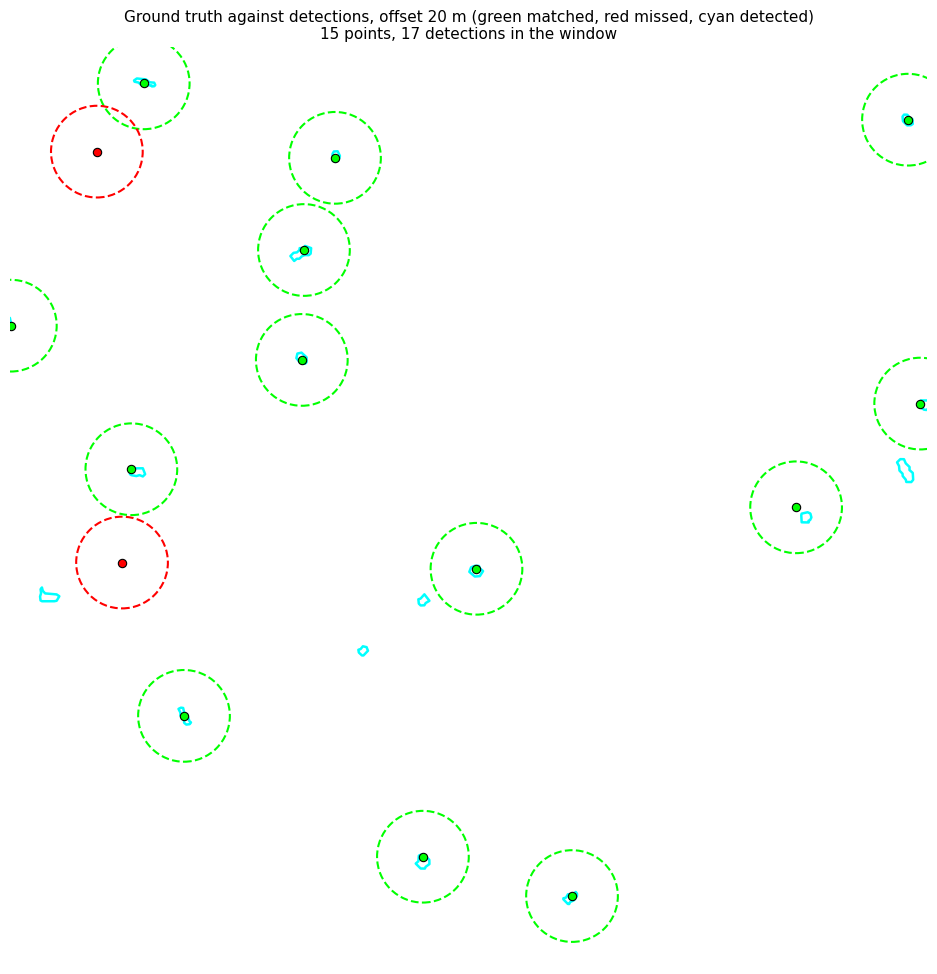

In [11]:
import io
import requests
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from PIL import Image

ZONE_CENTER = None      # (lon, lat); None lets ZONE_MODE choose
ZONE_MODE = 'representative'   # 'representative': a dense window holding both matched and missed
                               # points. 'borderline': a point with a detection 10 to 50 m away,
                               # which is the case that actually tests the offset.
ZONE_HALF_M = 200       # half-width of the window, in metres
# exemples de zones representatives (auto-detectees) : (1.32376, 43.58305) dept 31 — 14 pts (12 TP/2 FN)
#   (4.83268, 44.13096) dept 84 — 14 pts (9/5) ; (-0.76426, 44.89719) dept 33 — 13 pts (7/6)
WMS_PX = 1024

IGN_WMS_L93 = ("https://data.geopf.fr/wms-r/wms?SERVICE=WMS&VERSION=1.3.0&REQUEST=GetMap"
               "&LAYERS=HR.ORTHOIMAGERY.ORTHOPHOTOS&EXCEPTIONS=text/xml&FORMAT=image/png"
               "&STYLES=&CRS=EPSG:2154&BBOX={},{},{},{}&WIDTH={}&HEIGHT={}")

if ZONE_CENTER is None:
    if ZONE_MODE == 'borderline':
        # Borderline: a point with a nearby but not immediate detection
        border = matched[(matched['dist_m'] > 10) & (matched['dist_m'] < 50)]
        ex = border.sample(1, random_state=42).iloc[0] if len(border) else matched.iloc[0]
        cx, cy = ex.geometry.x, ex.geometry.y      # metric projection
    else:
        # Representative: the densest window holding both matched and missed points
        gx = (matched.geometry.x // (2 * ZONE_HALF_M)).astype(int)
        gy = (matched.geometry.y // (2 * ZONE_HALF_M)).astype(int)
        cells_stats = matched.assign(gx=gx, gy=gy).groupby(['gx', 'gy'])['pred'].agg(['size', 'sum'])
        cells_stats = cells_stats[(cells_stats['sum'] >= 2) & (cells_stats['size'] - cells_stats['sum'] >= 1)]
        best = cells_stats['size'].idxmax()
        sel = matched[(gx == best[0]) & (gy == best[1])]
        cx, cy = sel.geometry.x.mean(), sel.geometry.y.mean()
else:
    g = gpd.GeoSeries(gpd.points_from_xy([ZONE_CENTER[0]], [ZONE_CENTER[1]]), crs=WGS84).to_crs(LAMBERT93)
    cx, cy = g.iloc[0].x, g.iloc[0].y

bbox = (cx - ZONE_HALF_M, cy - ZONE_HALF_M, cx + ZONE_HALF_M, cy + ZONE_HALF_M)

fig, ax = plt.subplots(figsize=(10, 10))
try:
    r = requests.get(IGN_WMS_L93.format(*bbox, WMS_PX, WMS_PX), timeout=30)
    r.raise_for_status()
    ax.imshow(Image.open(io.BytesIO(r.content)), extent=[bbox[0], bbox[2], bbox[1], bbox[3]])
except Exception as e:
    print(f"basemap unavailable ({e}) -- drawing without it")

# Detections inside the window
win = detections.cx[bbox[0]:bbox[2], bbox[1]:bbox[3]]
if len(win):
    win.plot(ax=ax, facecolor='none', edgecolor='cyan', linewidth=1.8)

# Ground-truth points, with their offset circles
pts_win = matched.cx[bbox[0]:bbox[2], bbox[1]:bbox[3]]
for _, row in pts_win.iterrows():
    color = 'lime' if row['pred'] == 1 else 'red'
    ax.plot(row.geometry.x, row.geometry.y, 'o', color=color, markersize=6,
            markeredgecolor='black', markeredgewidth=0.8)
    ax.add_patch(Circle((row.geometry.x, row.geometry.y), MATCH_MAX_DIST_M,
                         fill=False, edgecolor=color, linewidth=1.5, linestyle='--'))

ax.set_xlim(bbox[0], bbox[2]); ax.set_ylim(bbox[1], bbox[3])
ax.set_aspect('equal'); ax.set_axis_off()
ax.set_title(f"Ground truth against detections, offset {MATCH_MAX_DIST_M:.0f} m "
             f"(green matched, red missed, cyan detected)\n"
             f"{len(pts_win)} points, {len(win)} detections in the window", fontsize=11)
plt.tight_layout()
plt.show()


## 9. Diagnostics

**The offset.** Recall should be stable around the chosen value. A plateau means matched and missed
points separate cleanly; a continuous slope means the threshold is capturing neighbouring
installations, and the choice of offset would then be doing analytical work it should not.

**Temporally ambiguous points.** The recall gap between certainly-anterior and ambiguous points. If
the ambiguous ones pull recall noticeably down, some of them genuinely postdate the survey and
keeping them is costing accuracy.

**Size.** Recall by size band, on the sized subset only. This tests the homogeneity assumption
directly, and it is the same question specification B bounds downstream.

**Ground-truth quality tests live in `quality_assessment/`**: source concordance at constant
department and the vintage effect in `gt_bias_tests.ipynb`; label agreement and the false-miss
re-review in `kappa.ipynb`.

Results to date: no detectable source bias, the national OSM-versus-manual gap being a composition
effect, and no vintage effect once local detection quality is controlled for.

In [12]:
dist_all = matched['dist_m']
for d in [0, 5, 10, 20, 35, 50]:
    print(f"  offset {d:>3} m : recall national = {(dist_all <= d).mean():.3f}")


  offset   0 m : recall national = 0.439
  offset   5 m : recall national = 0.568
  offset  10 m : recall national = 0.588
  offset  20 m : recall national = 0.601
  offset  35 m : recall national = 0.631
  offset  50 m : recall national = 0.663


In [13]:
print(recall_points.groupby('temporal_status')['pred'].agg(['mean', 'count']))


                     mean  count
temporal_status                 
ambiguous        0.549356    932
anterior         0.605363  11821


In [14]:
has_kwp = matched['kWp_est'].notna()
bins = [0, 3, 9, 36, np.inf]
labels_bins = ['0-3 kWp', '3-9 kWp', '9-36 kWp', '>36 kWp']
by_size = (matched[has_kwp]
           .assign(size_bin=pd.cut(matched.loc[has_kwp, 'kWp_est'], bins, labels=labels_bins))
           .groupby('size_bin', observed=True)['pred'].agg(['mean', 'count']))
print(by_size)


              mean  count
size_bin                 
0-3 kWp   0.515832   1737
3-9 kWp   0.703302   4422
9-36 kWp  0.628280   2058


## 10. Annotation effort: bringing every unit up to the floor

The same logic as on the precision side: how many ground-truth points each unit is short of its
floor. The shortfall is filled by manual annotation, a point on or beside an installation visible on
the imagery, and the notebook picks them up on the next run.

The floor can be raised per unit, which is worth doing for the units that weigh most in the national
total: uncertainty there costs more than the same uncertainty in a small unit.

In [15]:
MIN_ANNOTATIONS = 80

# Optional per-unit override
min_samples_override = {}

counts = recall_points.groupby('dpt').size().rename('n_current').to_frame()
counts['min_required'] = counts.index.map(min_samples_override).fillna(MIN_ANNOTATIONS).astype(int)
counts['n_missing'] = (counts['min_required'] - counts['n_current']).clip(lower=0)

deficit = counts[counts['n_missing'] > 0].sort_values('n_missing', ascending=False)
print(f"{len(deficit)} unit(s) below the floor of {MIN_ANNOTATIONS} points:")
if len(deficit):
    print(deficit.to_string())
print(f"\nTOTAL a annoter : {int(counts['n_missing'].sum())} points")


31 unit(s) below the floor of 80 points:
     n_current  min_required  n_missing
dpt                                    
2B           4            80         76
14           9            80         71
2A          10            80         70
26          32            80         48
86          33            80         47
04          35            80         45
13          37            80         43
69          44            80         36
35          46            80         34
05          52            80         28
28          52            80         28
59          53            80         27
23          56            80         24
47          58            80         22
51          58            80         22
73          60            80         20
50          62            80         18
60          63            80         17
18          64            80         16
02          70            80         10
77          71            80          9
57          73            80          7